# Face-emotion CNN training (GPU)


In [1]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (go set Runtime > GPU!)')

CUDA available: True
Device: Tesla T4


In [2]:
from google.colab import files
print('Upload your kaggle.json (from C:\\Users\\ABZ13\\.kaggle\\kaggle.json)')
uploaded = files.upload()

Upload your kaggle.json (from C:\Users\ABZ13\.kaggle\kaggle.json)


Saving access_token to access_token


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets download -d fatihkgg/affectnet-yolo-format -p /content/data --unzip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/fatihkgg/affectnet-yolo-format
License(s): MIT
100% 258M/258M [00:13<00:00, 19.7MB/s]



In [4]:
import os
from PIL import Image
from torch.utils.data import Dataset

CLASS_NAMES = ['Anger', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

class AffectNetYolo(Dataset):
    def __init__(self, root, split, transform=None):
        img_dir = os.path.join(root, split, 'images')
        label_dir = os.path.join(root, split, 'labels')
        self.transform = transform
        self.samples = []
        for fname in os.listdir(img_dir):
            stem = os.path.splitext(fname)[0]
            label_path = os.path.join(label_dir, stem + '.txt')
            if not os.path.isfile(label_path):
                continue
            with open(label_path) as fh:
                line = fh.readline().strip()
            if not line:
                continue
            cls = int(line.split()[0])
            self.samples.append((os.path.join(img_dir, fname), cls))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, cls

    def class_counts(self):
        counts = [0] * len(CLASS_NAMES)
        for _, cls in self.samples:
            counts[cls] += 1
        return counts

In [5]:
import torch.nn as nn

class EmotionCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [6]:
import time
import torch
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms

DATA_ROOT = '/content/data/YOLO_format'
RESULTS_DIR = '/content/results'
CKPT_PATH = os.path.join(RESULTS_DIR, 'face_emotion_classifier.pt')
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 6
LR = 1e-3

MEAN = [0.5, 0.5, 0.5]
STD = [0.5, 0.5, 0.5]

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Device:', DEVICE)

Device: cuda


In [7]:
train_ds = AffectNetYolo(DATA_ROOT, 'train', transform=train_tf)
val_ds = AffectNetYolo(DATA_ROOT, 'valid', transform=eval_tf)
test_ds = AffectNetYolo(DATA_ROOT, 'test', transform=eval_tf)
print(f'train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}')

counts = train_ds.class_counts()
total = sum(counts)
weights = torch.tensor([total / (len(CLASS_NAMES) * c) for c in counts], dtype=torch.float32)
print('class counts:', dict(zip(CLASS_NAMES, counts)))
print('class weights:', dict(zip(CLASS_NAMES, [round(w, 2) for w in weights.tolist()])))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train=17101 val=5406 test=2755
class counts: {'Anger': 2339, 'Contempt': 1996, 'Disgust': 2242, 'Fear': 2021, 'Happy': 2154, 'Neutral': 1616, 'Sad': 1914, 'Surprise': 2819}
class weights: {'Anger': 0.91, 'Contempt': 1.07, 'Disgust': 0.95, 'Fear': 1.06, 'Happy': 0.99, 'Neutral': 1.32, 'Sad': 1.12, 'Surprise': 0.76}


In [8]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            preds = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, macro_f1, all_labels, all_preds


def plot_confusion(labels, preds, path):
    cm = confusion_matrix(labels, preds, labels=list(range(len(CLASS_NAMES))))
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
    fig.colorbar(im)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()

epoch 01  train_loss=2.0713  val_acc=0.2312  val_macro_f1=0.1566  (42s)
epoch 02  train_loss=1.8564  val_acc=0.3158  val_macro_f1=0.2596  (30s)
epoch 03  train_loss=1.6951  val_acc=0.3679  val_macro_f1=0.3154  (29s)
epoch 04  train_loss=1.5800  val_acc=0.2801  val_macro_f1=0.2222  (30s)
epoch 05  train_loss=1.4983  val_acc=0.4684  val_macro_f1=0.4170  (30s)
epoch 06  train_loss=1.4348  val_acc=0.5035  val_macro_f1=0.4732  (31s)
epoch 07  train_loss=1.3952  val_acc=0.4983  val_macro_f1=0.4600  (29s)
epoch 08  train_loss=1.3564  val_acc=0.4686  val_macro_f1=0.4225  (30s)
epoch 09  train_loss=1.3228  val_acc=0.5990  val_macro_f1=0.5940  (33s)
epoch 10  train_loss=1.2934  val_acc=0.5597  val_macro_f1=0.5348  (32s)
epoch 11  train_loss=1.2662  val_acc=0.6145  val_macro_f1=0.6089  (32s)
epoch 12  train_loss=1.2425  val_acc=0.5026  val_macro_f1=0.4877  (32s)
epoch 13  train_loss=1.2253  val_acc=0.5694  val_macro_f1=0.5678  (30s)
epoch 14  train_loss=1.2059  val_acc=0.6077  val_macro_f1=0.5682

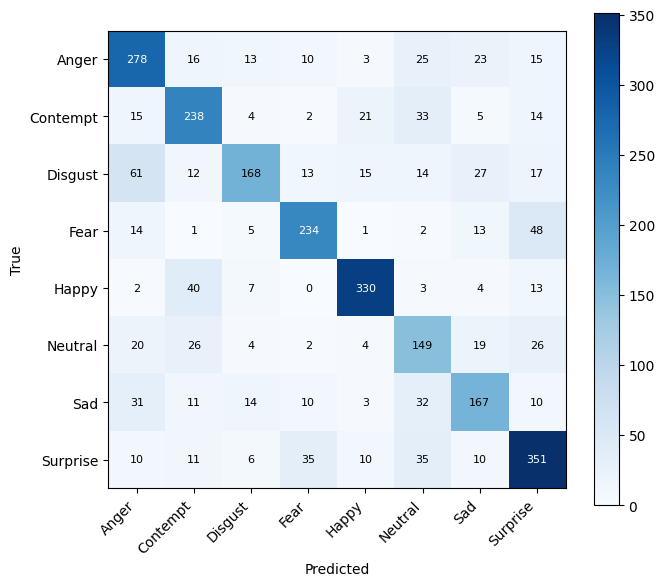

In [9]:
model = EmotionCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE), label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_f1 = -1.0
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(train_ds)

    val_acc, val_f1, _, _ = evaluate(model, val_loader)
    scheduler.step(val_f1)
    dt = time.time() - t0
    print(f'epoch {epoch:02d}  train_loss={train_loss:.4f}  val_acc={val_acc:.4f}  '
          f'val_macro_f1={val_f1:.4f}  ({dt:.0f}s)')

    if val_f1 > best_f1:
        best_f1 = val_f1
        epochs_no_improve = 0
        torch.save({'model_state': model.state_dict(), 'class_names': CLASS_NAMES}, CKPT_PATH)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs)')
            break

print('\nLoading best checkpoint for final test evaluation...')
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
test_acc, test_f1, labels, preds = evaluate(model, test_loader)
print(f'TEST  acc={test_acc:.4f}  macro_f1={test_f1:.4f}')

per_class_f1 = f1_score(labels, preds, average=None)
for name, f1 in zip(CLASS_NAMES, per_class_f1):
    print(f'  {name:<10} f1={f1:.3f}')

plot_confusion(labels, preds, os.path.join(RESULTS_DIR, 'face_emotion_confusion_matrix.png'))

In [10]:
from google.colab import files
files.download('/content/results/face_emotion_classifier.pt')
files.download('/content/results/face_emotion_confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>